In [2]:
import numpy as np

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [8, 8],
    [8, 9],
    [9, 8]
])

print(X)




[[1 1]
 [1 2]
 [2 1]
 [8 8]
 [8 9]
 [9 8]]


Text(0, 0.5, 'Distance')

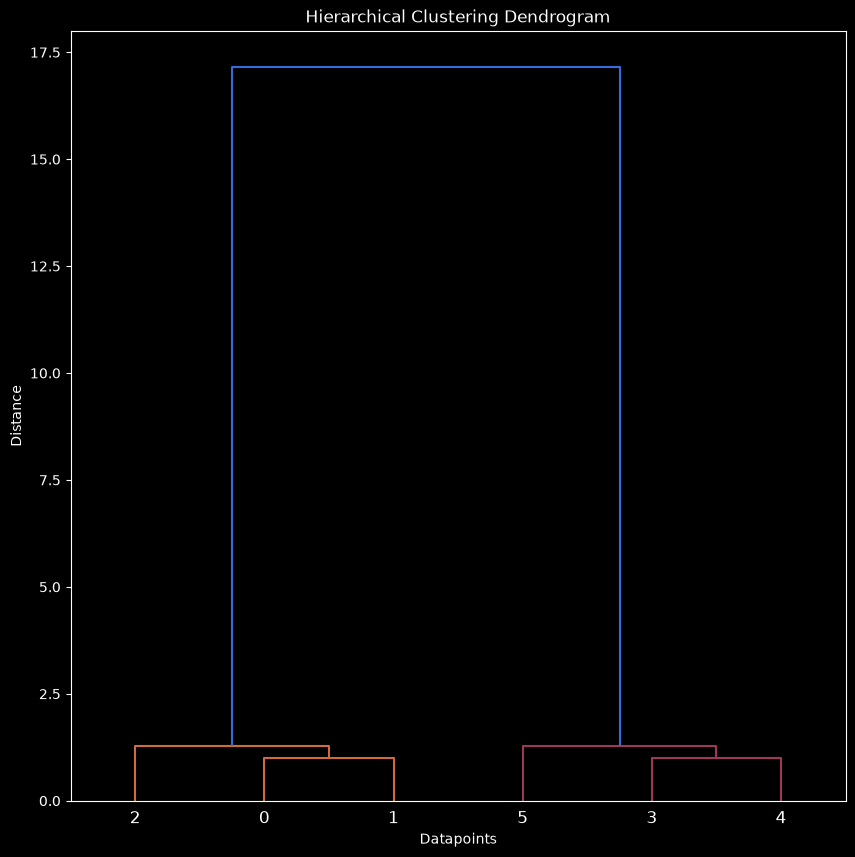

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt


Z=linkage(X, method='ward')
plt.figure(figsize=(10,10))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Datapoints")
plt.ylabel("Distance")

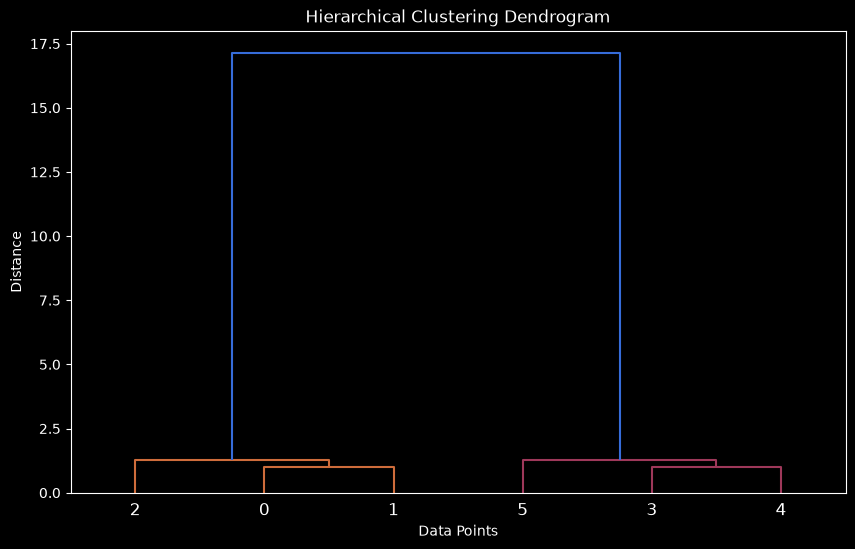

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [8, 8],
    [8, 9],
    [9, 8]
])

Z = linkage(X, method="ward")

plt.figure(figsize=(10, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

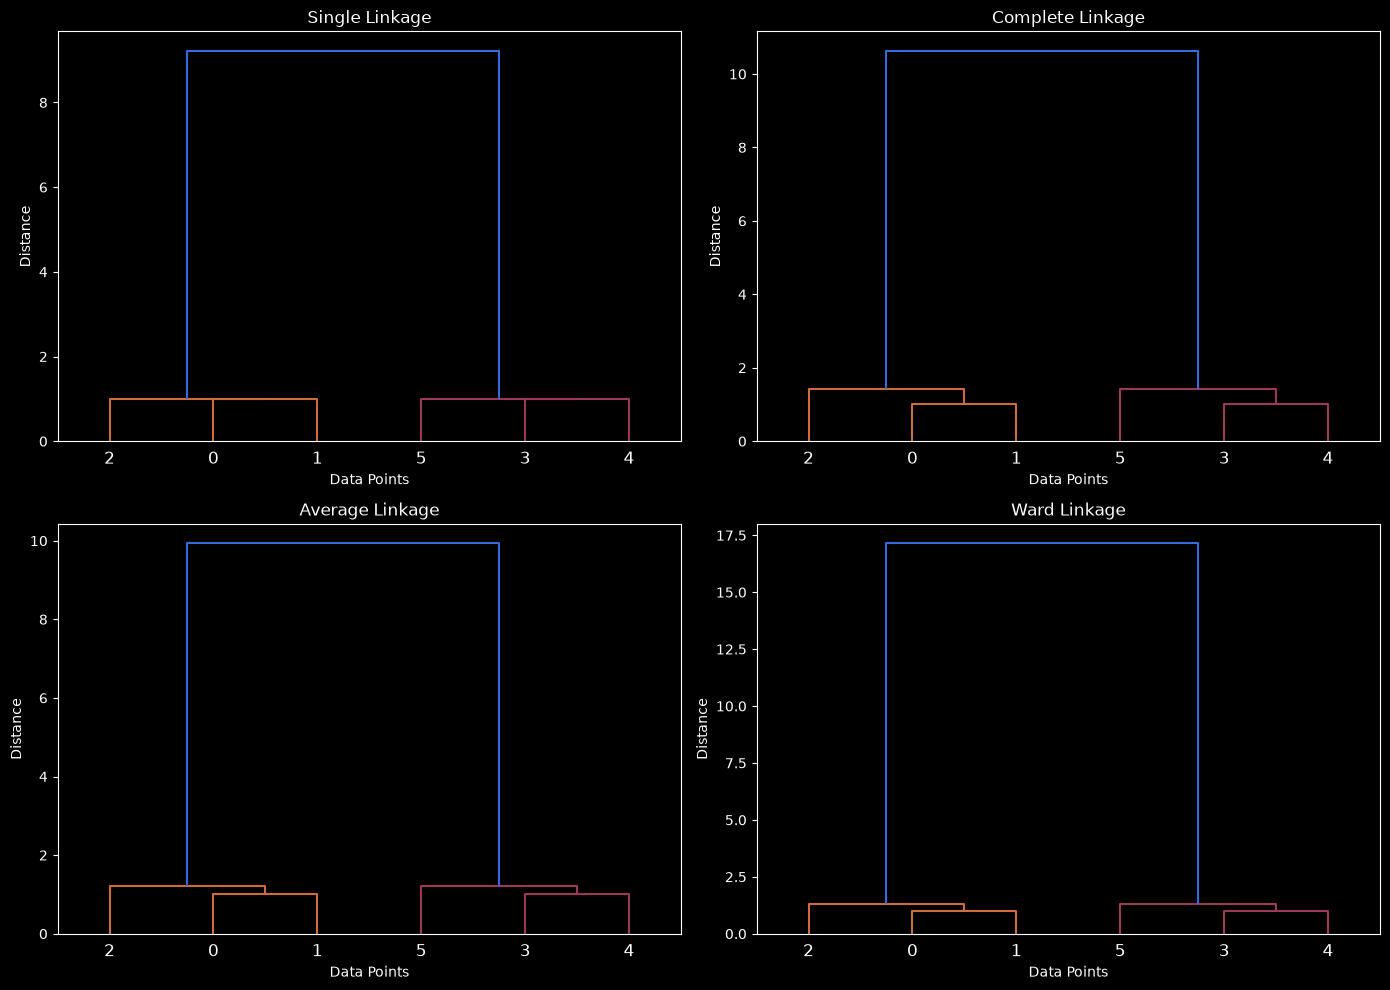

In [6]:
methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, method in zip(axes.ravel(), methods):

    Z = linkage(X, method=method)

    dendrogram(
        Z,
        ax=ax
    )

    ax.set_title(f"{method.title()} Linkage")
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# HIERARCHICAL CLUSTERING
# DATA CLEANING + ENCODING + SCALING
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Load the original dataset
# ------------------------------------------------------------

df = pd.read_csv("Test.csv")

print("Original shape:", df.shape)
display(df.head())


# ------------------------------------------------------------
# 2. Check missing values
# ------------------------------------------------------------

print("\nMissing values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 3. Handle missing values
# ------------------------------------------------------------

df["Ever_Married"] = df["Ever_Married"].fillna(
    df["Ever_Married"].mode()[0]
)

df["Graduated"] = df["Graduated"].fillna(
    df["Graduated"].mode()[0]
)

df["Profession"] = df["Profession"].fillna("Unknown")

df["Work_Experience"] = df["Work_Experience"].fillna(
    df["Work_Experience"].median()
)

df["Family_Size"] = df["Family_Size"].fillna(
    df["Family_Size"].median()
)

df["Var_1"] = df["Var_1"].fillna(
    df["Var_1"].mode()[0]
)


# ------------------------------------------------------------
# 4. Remove ID
# ------------------------------------------------------------

df = df.drop("ID", axis=1)


# ------------------------------------------------------------
# 5. Encode categorical variables
# ------------------------------------------------------------

categorical_columns = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Spending_Score",
    "Var_1"
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    dtype=int
)

print("\nAfter encoding:")
print("Shape:", df_encoded.shape)


# ------------------------------------------------------------
# 6. Separate features
# ------------------------------------------------------------

X = df_encoded


# ------------------------------------------------------------
# 7. Standardize features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ------------------------------------------------------------
# 8. Check result
# ------------------------------------------------------------

print("\nScaled data shape:", X_scaled.shape)

print("\nFirst 5 rows of scaled data:")
print(X_scaled[:5])

Original shape: (2627, 10)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6



Missing values:
ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience    269
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64

After encoding:
Shape: (2627, 29)

Scaled data shape: (2627, 29)

First 5 rows of scaled data:
[[-0.45094833 -0.74810537 -1.17209743  1.08798318 -1.08798318 -0.82051716
   0.82051716 -0.78461529  0.78461529 -0.6629118  -0.31853964  3.1829791
  -0.35973144 -0.26796908 -0.43500103 -0.17949941 -0.30307375 -0.21004201
  -0.12115066 -0.5587377  -0.41502353  0.79096069 -0.11450863 -0.23815461
  -0.33635635 -0.41502353 -0.10565241  0.73598007 -0.16053406]
 [-0.39199923  1.7522417   0.79244954 -0.91913186  0.91913186 -0.82051716
   0.82051716 -0.78461529  0.78461529 -0.6629118  -0.31853964 -0.31417109
  -0.35973144 -0.26796908  2.29884514 -0.17949941 -0.30307375 -0.21004201
  -0.12115066  1.78974859 -0.41502353 -1.26428534 -0.11450863 -0

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Create hierarchical clustering structure
Z = linkage(X_scaled, method="ward")

print("Linkage matrix shape:", Z.shape)

Linkage matrix shape: (2626, 4)
